In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print(f"SHAP version: {shap.__version__}")
print("✓ Imports ready")

/opt/anaconda3/envs/customer_analytics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0
✓ Imports ready


In [ ]:
FEATURES = [
    'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'ARR_HOUR', 'IS_HOLIDAY',
    'DISTANCE', 'profit_margin', 'origin_monthly_passengers',
    'origin_temp', 'origin_dew_point', 'origin_pressure',
    'origin_wind_dir', 'origin_wind_speed', 'origin_precip_1hr',
    'origin_weather_severity',
    'dest_temp', 'dest_dew_point', 'dest_pressure',
    'dest_wind_dir', 'dest_wind_speed', 'dest_precip_1hr',
    'dest_weather_severity',
    'airline_delay_rate_30d', 'origin_delay_rate_30d', 'dest_delay_rate_30d',
    'route_delay_rate_30d', 'origin_avg_taxi_out_30d',
    'flight_num_delay_rate_30d', 'origin_hour_delay_rate_30d',
    'carrier_origin_delay_rate_30d', 'dest_hour_delay_rate_30d',
    'airline_delay_rate_7d', 'origin_delay_rate_7d',
    'cascade_score', 'cascade_delay_minutes', 'hours_since_last_delay',
    'hourly_flight_count', 'scheduled_turnaround_buffer', 'tail_flight_num_today',
    'dest_hourly_flight_count',
    'inbound_arr_delay_3h', 'dest_inbound_arr_delay_3h',
    'prev_tail_arr_delay', 'national_hub_delay_2h',
    'OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'airline_cluster_label',
    'origin_pressure_delta_3h', 'dest_pressure_delta_3h',
    'origin_wind_speed_delta_3h', 'dest_wind_speed_delta_3h',
    'day_of_year',
    'origin_dep_delay_rate_1h', 'dest_dep_delay_rate_1h',
    'origin_stress_index', 'real_time_turn_gap',
    'tail_delays_today', 'tail_active_hours',
    'origin_pressure_drop_stress', 'airport_fatigue_index',
]
CAT_FEATURES = ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'airline_cluster_label']
TARGET = 'ARR_DEL15'

model = joblib.load('models/lgbm_delay_classifier_final.pkl')
print(f"Model loaded: {model.best_iteration_} iterations, AUC 0.8629")

Model loaded: 7162 iterations, AUC 0.8629


In [ ]:
flights = pd.read_parquet('dataset/merged_flights_fe_v2.parquet')
for col in CAT_FEATURES:
    flights[col] = flights[col].astype('category')

test = flights[flights['FL_DATE'] >= '2025-01-01']
X_test = test[FEATURES].copy()
y_test = test[TARGET].copy()

del flights, test

np.random.seed(42)
delayed_idx = y_test[y_test == 1].index
ontime_idx  = y_test[y_test == 0].index
delay_rate  = y_test.mean()

sample_idx = np.concatenate([
    np.random.choice(delayed_idx, size=int(50000 * delay_rate), replace=False),
    np.random.choice(ontime_idx, size=int(50000 * (1 - delay_rate)), replace=False),
])
np.random.shuffle(sample_idx)

X_shap = X_test.loc[sample_idx]
y_shap = y_test.loc[sample_idx]

print(f"Test set: {X_test.shape[0]:,}")
print(f"SHAP sample: {X_shap.shape[0]:,}  |  Delay rate: {y_shap.mean():.4f}")
print("✓ Ready for SHAP")

Test set: 4,519,126
SHAP sample: 49,999  |  Delay rate: 0.2296
✓ Ready for SHAP


In [ ]:
import time

start = time.time()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
elapsed = time.time() - start

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}")
print(f"Computation time: {elapsed/60:.1f} minutes")
print(f"Expected value (base rate log-odds): {explainer.expected_value}")
print("✓ SHAP values computed")

SHAP values shape: (49999, 61)
Computation time: 27.1 minutes
Expected value (base rate log-odds): -0.3670924519707588
✓ SHAP values computed


In [ ]:
shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False)

print("SHAP Global Feature Importance (Top 20):")
print("-" * 50)
for i, row in shap_importance.head(20).iterrows():
    bar = "█" * int(row['mean_abs_shap'] / shap_importance['mean_abs_shap'].max() * 40)
    print(f"  {row['feature']:<35} {row['mean_abs_shap']:.4f}  {bar}")

print(f"\n{'=' * 50}")
print("LightGBM split importance vs SHAP importance (Top 10):")
print(f"{'Feature':<35} {'SHAP Rank':<12} {'Split Rank':<12}")
print("-" * 60)

split_importance = pd.DataFrame({
    'feature': FEATURES,
    'split_imp': model.feature_importances_,
}).sort_values('split_imp', ascending=False)

for rank, (_, row) in enumerate(shap_importance.head(10).iterrows(), 1):
    split_rank = split_importance.index.get_loc(
        split_importance[split_importance['feature'] == row['feature']].index[0]
    ) + 1
    print(f"  {row['feature']:<35} #{rank:<10} #{split_rank:<10}")

SHAP Global Feature Importance (Top 20):
--------------------------------------------------
  real_time_turn_gap                  0.7733  ████████████████████████████████████████
  scheduled_turnaround_buffer         0.2756  ██████████████
  prev_tail_arr_delay                 0.2743  ██████████████
  dest_inbound_arr_delay_3h           0.2523  █████████████
  airport_fatigue_index               0.1557  ████████
  ORIGIN                              0.1062  █████
  OP_UNIQUE_CARRIER                   0.1027  █████
  flight_num_delay_rate_30d           0.1023  █████
  DEST                                0.0962  ████
  DEP_HOUR                            0.0846  ████
  tail_delays_today                   0.0819  ████
  origin_dep_delay_rate_1h            0.0801  ████
  tail_flight_num_today               0.0732  ███
  origin_delay_rate_30d               0.0704  ███
  inbound_arr_delay_3h                0.0643  ███
  cascade_delay_minutes               0.0636  ███
  ARR_HOUR              

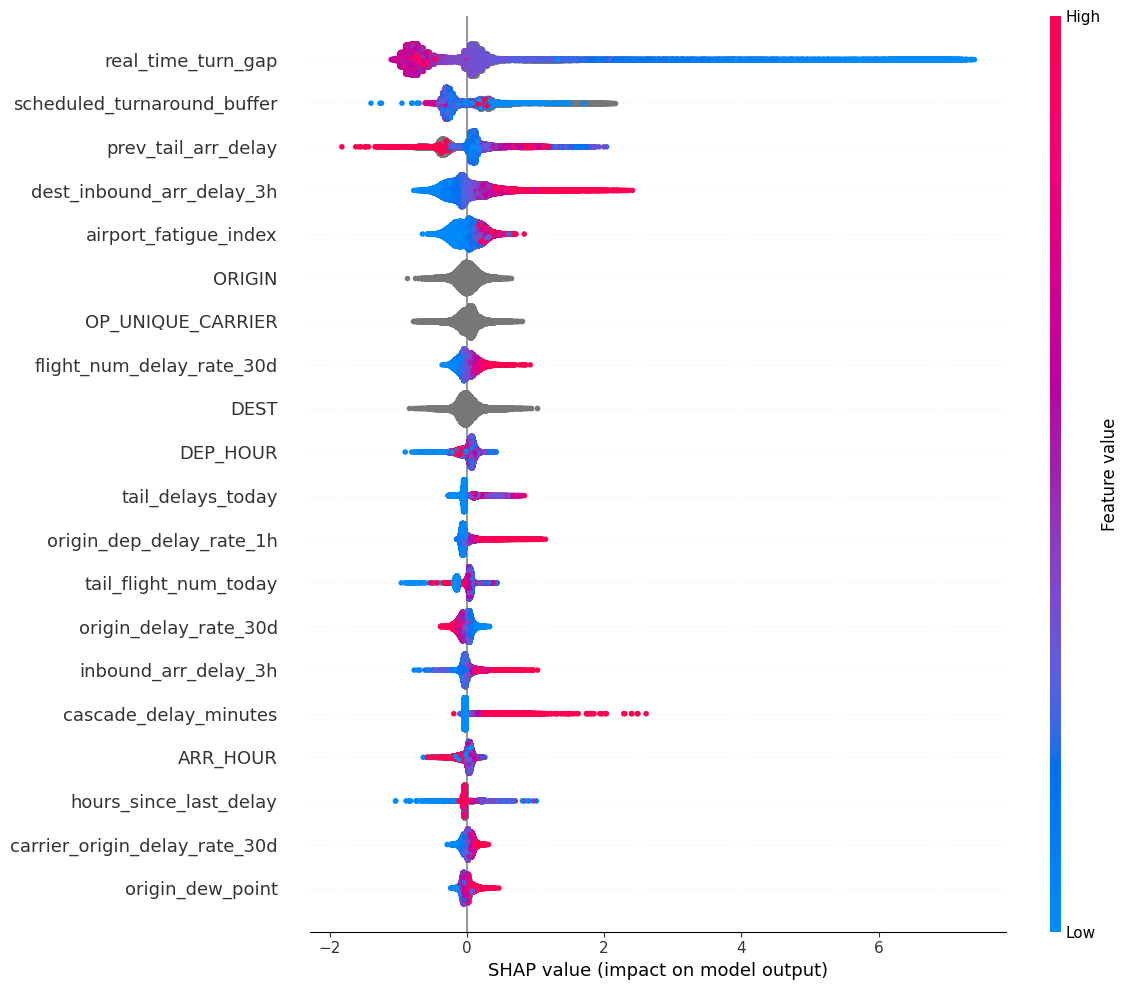

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    max_display=20,
    show=True,
    plot_size=(12, 10),
)

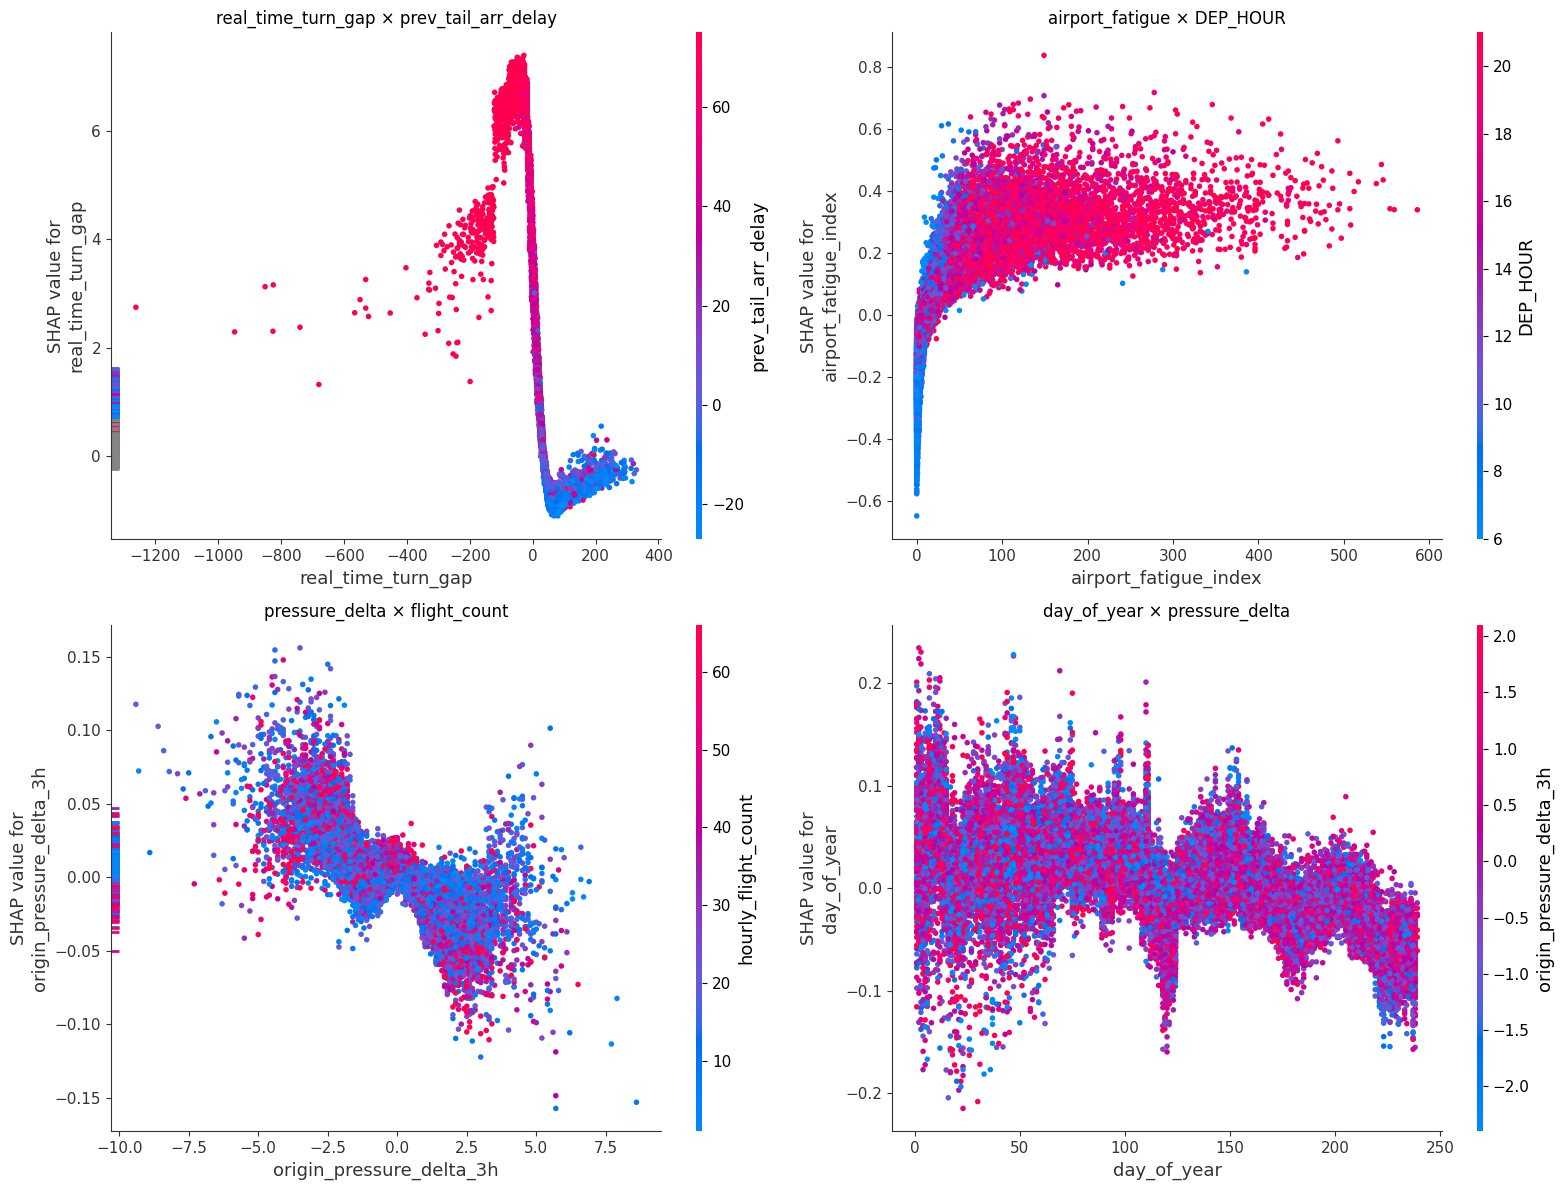

✓ Saved: models/shap_dependence_plots_v2.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

shap.dependence_plot(
    'real_time_turn_gap', shap_values, X_shap,
    interaction_index='prev_tail_arr_delay',
    ax=axes[0, 0], show=False,
)
axes[0, 0].set_title('real_time_turn_gap × prev_tail_arr_delay')

shap.dependence_plot(
    'airport_fatigue_index', shap_values, X_shap,
    interaction_index='DEP_HOUR',
    ax=axes[0, 1], show=False,
)
axes[0, 1].set_title('airport_fatigue × DEP_HOUR')

shap.dependence_plot(
    'origin_pressure_delta_3h', shap_values, X_shap,
    interaction_index='hourly_flight_count',
    ax=axes[1, 0], show=False,
)
axes[1, 0].set_title('pressure_delta × flight_count')

shap.dependence_plot(
    'day_of_year', shap_values, X_shap,
    interaction_index='origin_pressure_delta_3h',
    ax=axes[1, 1], show=False,
)
axes[1, 1].set_title('day_of_year × pressure_delta')

plt.tight_layout()
plt.savefig('models/shap_dependence_plots_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: models/shap_dependence_plots_v2.png")

High-risk flight: prob=1.000, actual=DELAYED
Low-risk flight:  prob=0.019, actual=ON-TIME


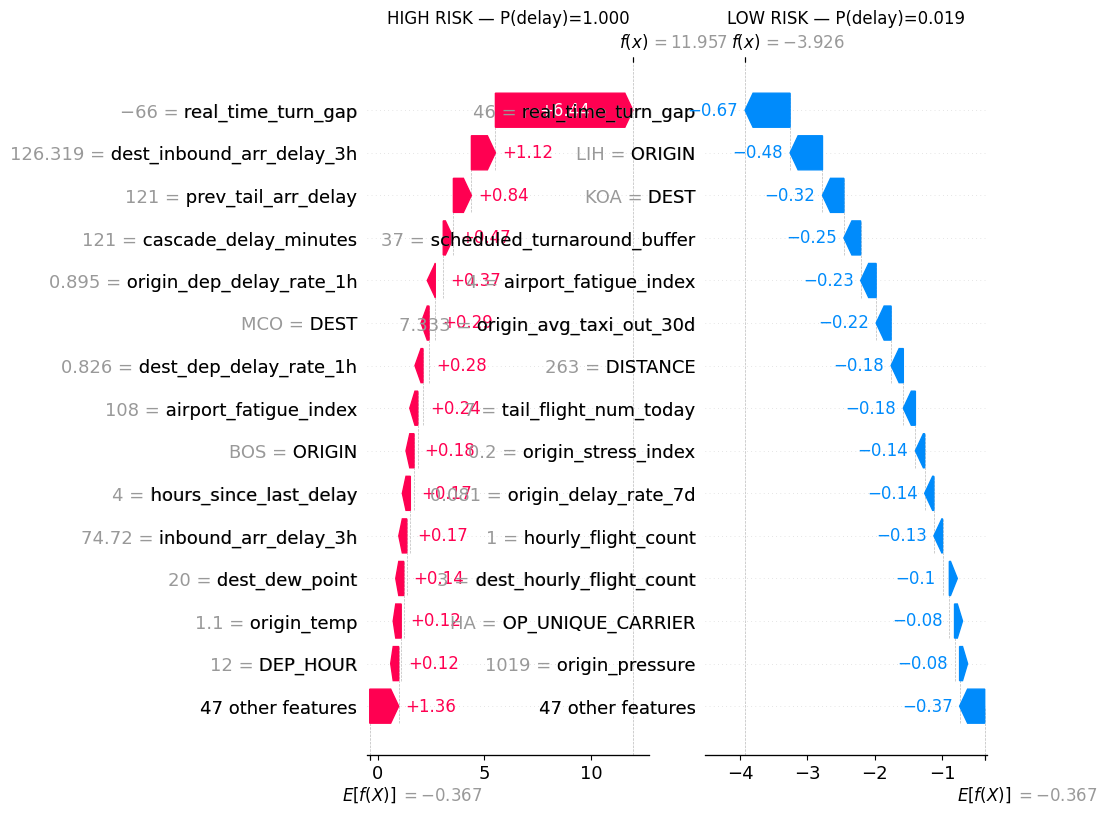

✓ Saved: models/shap_waterfall_examples.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

probs = model.predict_proba(X_shap)[:, 1]

delayed_mask = y_shap == 1
high_risk_idx = probs[delayed_mask].argmax()
high_risk_pos = y_shap[delayed_mask].index[high_risk_idx]
high_risk_loc = X_shap.index.get_loc(high_risk_pos)

ontime_mask = y_shap == 0
low_risk_idx = probs[~delayed_mask].argmin()
low_risk_pos = y_shap[~delayed_mask].index[low_risk_idx]
low_risk_loc = X_shap.index.get_loc(low_risk_pos)

print(f"High-risk flight: prob={probs[high_risk_loc]:.3f}, actual={'DELAYED' if y_shap.iloc[high_risk_loc]==1 else 'ON-TIME'}")
print(f"Low-risk flight:  prob={probs[low_risk_loc]:.3f}, actual={'DELAYED' if y_shap.iloc[low_risk_loc]==1 else 'ON-TIME'}")

plt.subplot(1, 2, 1)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_loc],
        base_values=explainer.expected_value,
        data=X_shap.iloc[high_risk_loc],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f"HIGH RISK — P(delay)={probs[high_risk_loc]:.3f}")

plt.subplot(1, 2, 2)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_loc],
        base_values=explainer.expected_value,
        data=X_shap.iloc[low_risk_loc],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f"LOW RISK — P(delay)={probs[low_risk_loc]:.3f}")

plt.tight_layout()
plt.savefig('models/shap_waterfall_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: models/shap_waterfall_examples.png")

SHAP values saved: (49999, 61)
SHAP sample saved: (49999, 61)


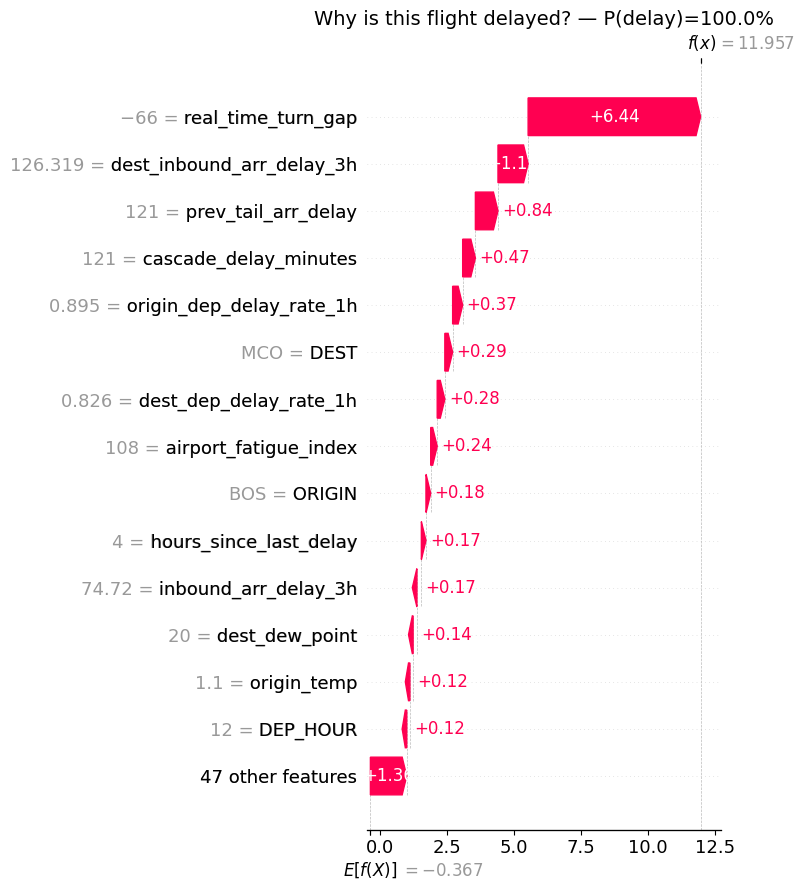

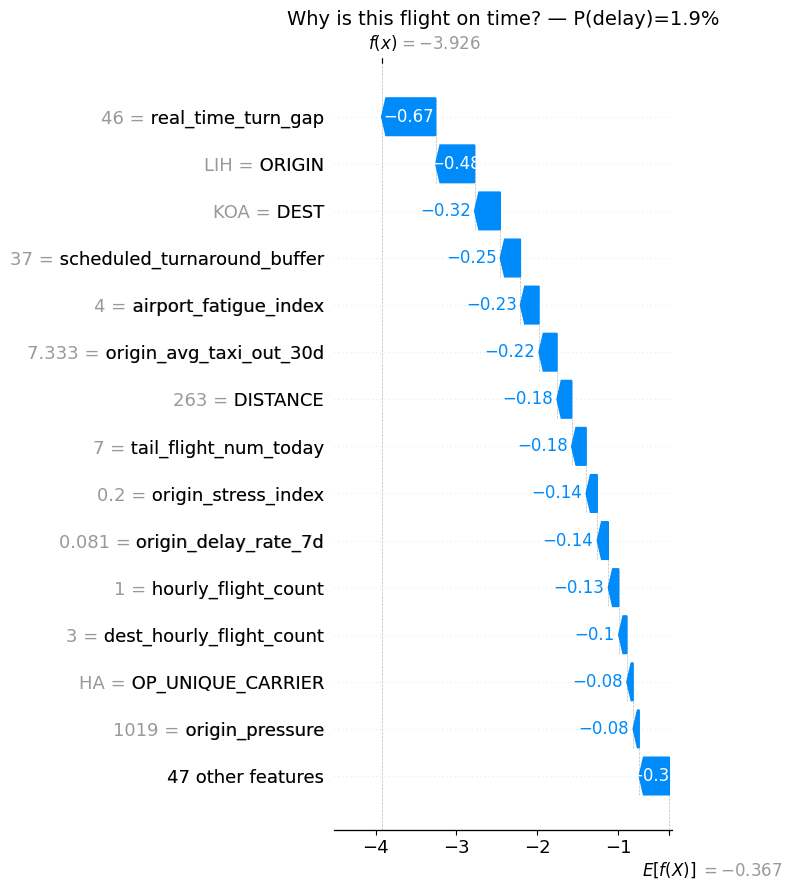


✓ All SHAP artifacts saved:
  models/shap_values_50k.npy
  models/shap_sample_X.parquet
  models/shap_sample_y.parquet
  models/shap_waterfall_high_risk.png
  models/shap_waterfall_low_risk.png
  models/shap_dependence_plots.png


In [ ]:
np.save('models/shap_values_50k.npy', shap_values)
X_shap.to_parquet('models/shap_sample_X.parquet')
y_shap.to_frame().to_parquet('models/shap_sample_y.parquet')
print(f"SHAP values saved: {shap_values.shape}")
print(f"SHAP sample saved: {X_shap.shape}")

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_loc],
        base_values=explainer.expected_value,
        data=X_shap.iloc[high_risk_loc],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f"Why is this flight delayed? — P(delay)={probs[high_risk_loc]:.1%}", fontsize=14)
plt.tight_layout()
plt.savefig('models/shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_loc],
        base_values=explainer.expected_value,
        data=X_shap.iloc[low_risk_loc],
        feature_names=FEATURES,
    ),
    max_display=15,
    show=False,
)
plt.title(f"Why is this flight on time? — P(delay)={probs[low_risk_loc]:.1%}", fontsize=14)
plt.tight_layout()
plt.savefig('models/shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All SHAP artifacts saved:")
print("  models/shap_values_50k.npy")
print("  models/shap_sample_X.parquet")
print("  models/shap_sample_y.parquet")
print("  models/shap_waterfall_high_risk.png")
print("  models/shap_waterfall_low_risk.png")
print("  models/shap_dependence_plots.png")

In [ ]:
probs = model.predict_proba(X_shap)[:, 1]

high_delay = y_shap[y_shap == 1].index
on_time = y_shap[y_shap == 0].index

idx1 = X_shap.index.get_loc(high_delay[probs[y_shap == 1].argmax()])

moderate_mask = (probs > 0.55) & (probs < 0.65) & (y_shap == 1)
idx2 = X_shap.index.get_loc(y_shap[moderate_mask].index[0])

borderline_mask = (probs > 0.35) & (probs < 0.45) & (y_shap == 0)
idx3 = X_shap.index.get_loc(y_shap[borderline_mask].index[0])

idx4 = X_shap.index.get_loc(on_time[probs[y_shap == 0].argmin()])

flights_to_explain = [
    (idx1, "EXTREME RISK"),
    (idx2, "MODERATE RISK"),
    (idx3, "BORDERLINE"),
    (idx4, "VERY LOW RISK"),
]

for idx, label in flights_to_explain:
    prob = probs[idx]
    actual = "DELAYED" if y_shap.iloc[idx] == 1 else "ON-TIME"
    print(f"\n{'=' * 60}")
    print(f"{label} — P(delay)={prob:.1%}, Actual: {actual}")
    print(f"{'=' * 60}")
    
    sv = shap_values[idx]
    feat_shap = sorted(zip(FEATURES, sv, X_shap.iloc[idx]), key=lambda x: abs(x[1]), reverse=True)
    
    print(f"  {'Feature':<35} {'SHAP':>8} {'Value':>12}")
    print(f"  {'-'*58}")
    for feat, shap_val, feat_val in feat_shap[:10]:
        direction = "→ DELAY" if shap_val > 0 else "→ ON-TIME"
        try:
            val_str = str(round(float(feat_val), 1))
        except (ValueError, TypeError):
            val_str = str(feat_val)
        print(f"  {feat:<35} {shap_val:>+8.3f} {val_str:>12}  {direction}")


EXTREME RISK — P(delay)=100.0%, Actual: DELAYED
  Feature                                 SHAP        Value
  ----------------------------------------------------------
  real_time_turn_gap                    +6.438        -66.0  → DELAY
  dest_inbound_arr_delay_3h             +1.125        126.3  → DELAY
  prev_tail_arr_delay                   +0.844        121.0  → DELAY
  cascade_delay_minutes                 +0.474        121.0  → DELAY
  origin_dep_delay_rate_1h              +0.374          0.9  → DELAY
  DEST                                  +0.291          MCO  → DELAY
  dest_dep_delay_rate_1h                +0.284          0.8  → DELAY
  airport_fatigue_index                 +0.243        108.0  → DELAY
  ORIGIN                                +0.177          BOS  → DELAY
  hours_since_last_delay                +0.172          4.0  → DELAY

MODERATE RISK — P(delay)=59.1%, Actual: DELAYED
  Feature                                 SHAP        Value
  -----------------------------